___

<a href='https://oxiane-institut.com/'> <img src='../oxiane.jpg' /></a>
___

# K Means Clustering Project

For this project, we will attempt to use KMeans Clustering to cluster Universities into two groups, Private and Public.

___
It is **very important to note that we actually have the labels for this dataset, but we will NOT use them for the KMeans clustering algorithm, since that is an unsupervised learning algorithm.**

When using the Kmeans algorithm under normal circumstances, it is because you don't have labels. In this case we will use the labels to try to get an idea of how well the algorithm performed, but you usually won't do this for Kmeans, so the classification report and confusion matrix at the end of this project don't really make sense in a real-world context!
___

## The Data

We will use a database with 777 observations on the following 18 variables.
* Private A factor with levels No and Yes indicating private or public university
* Apps Number of applications received
* Accept Number of applications accepted
* Enroll Number of new students enrolled
* Top10perc Pct. new students from top 10% of H.S. class
* Top25perc Pct. new students from top 25% of H.S. class
* F.Undergrad Number of fulltime undergraduates
* P.Undergrad Number of parttime undergraduates
* Outstate Out-of-state tuition
* Room.Board Room and board costs
* Books Estimated book costs
* Personal Estimated personal spending
* PhD Pct. of faculty with Ph.D.'s
* Terminal Pct. of faculty with terminal degree
* S.F.Ratio Student/faculty ratio
* perc.alumni Pct. alumni who donate
* Expend Instructional expenditure per student
* Grad.Rate Graduation rate

## Import libraries
 
**Import the libraries you usually use for data analysis.**

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [103]:
from sklearn.utils import check_random_state
import random

random.seed(42)
np.random.seed(42)
random_state = check_random_state(42)

## Get the data

**Read the College_Data file using read_csv. Figure out how to set the first column as the index.**

In [104]:
df = pd.read_csv('College_Data', index_col=0)

**Check the head of the data**

In [105]:
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


**Check the info() and describe() methods on the data.**

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777 entries, Abilene Christian University to York College of Pennsylvania
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: 

In [107]:
df.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


## EDA

It's time to create data visualizations!

**Create a scatter plot of Grad.Rate versus Room.Board where the points are colored by the Private column.**

<Axes: xlabel='Room.Board', ylabel='Grad.Rate'>

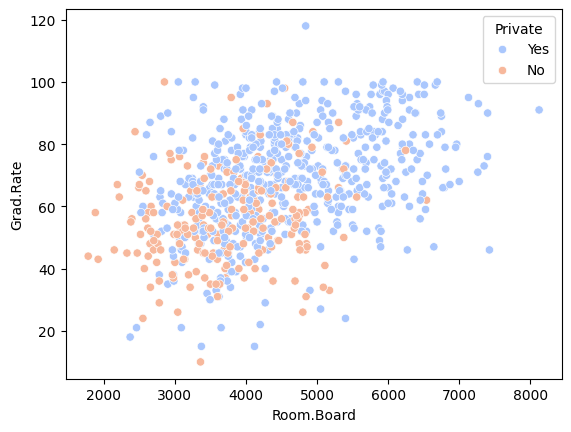

In [108]:
sns.scatterplot(x='Room.Board',y='Grad.Rate',data=df,hue='Private', palette='coolwarm')

**Create a scatter plot of F.Undergrad versus Outstate where the points are colored by the Private column.**

<Axes: xlabel='Outstate', ylabel='F.Undergrad'>

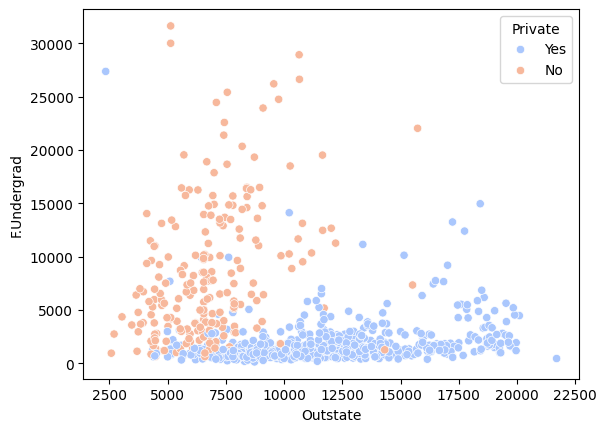

In [109]:
sns.scatterplot(x='Outstate',y='F.Undergrad',data=df,hue='Private', palette='coolwarm')

**Create a stacked histogram showing out-of-state tuition based on the Private column. Try to do this using [sns.FacetGrid](https://stanford.edu/~mwaskom/software/seaborn/generated/seaborn.FacetGrid.html).**

If it's too tricky, see if you can do it simply by using two instances of pandas.plot(kind='hist').

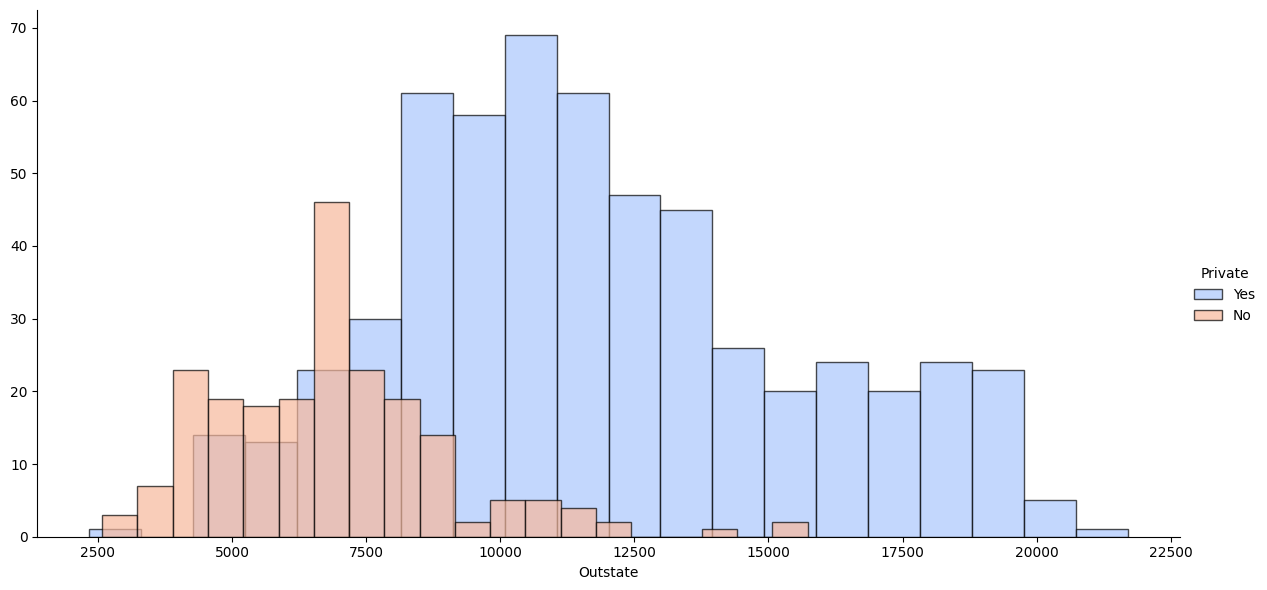

In [110]:
sns.FacetGrid(df,hue='Private',palette='coolwarm',height=6, aspect=2).map(plt.hist,'Outstate',bins=20,alpha=0.7, edgecolor='black').add_legend()

**Create a similar histogram for the Grad.Rate column.**

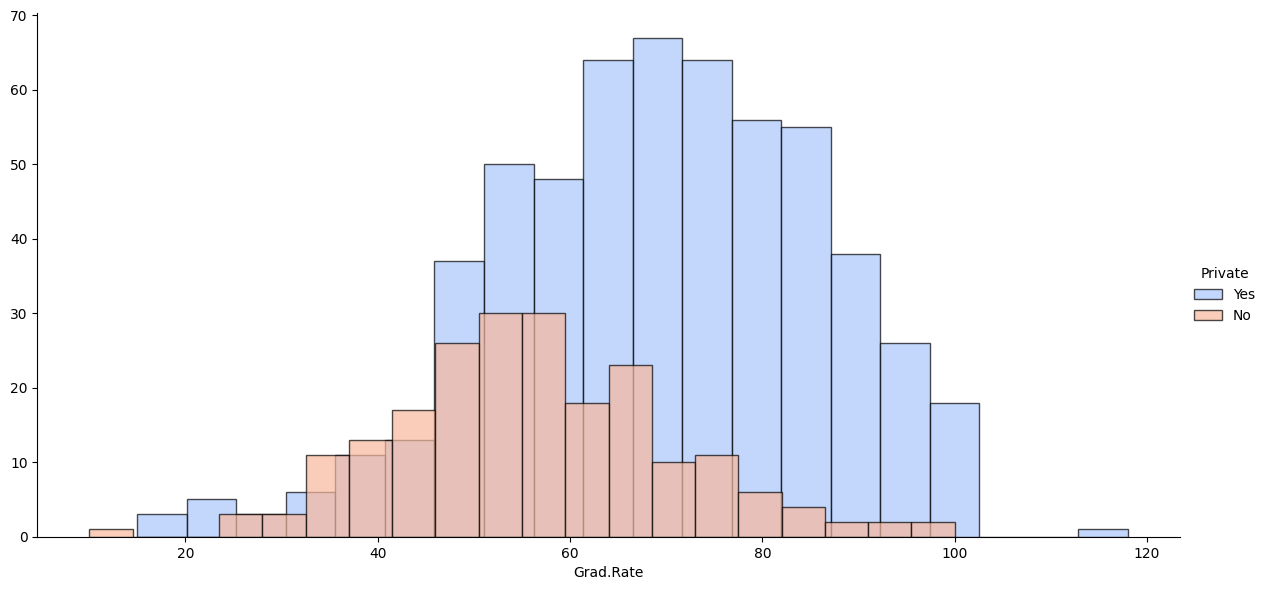

In [111]:
sns.FacetGrid(df,hue='Private',palette='coolwarm',height=6, aspect=2).map(plt.hist,'Grad.Rate',bins=20,alpha=0.7, edgecolor='black').add_legend()

**Notice that there seems to be a private school with a graduation rate higher than 100%. What is the name of this school?**

In [112]:
df[df['Grad.Rate']>100]

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Cazenovia College,Yes,3847,3433,527,9,35,1010,12,9384,4840,600,500,22,47,14.3,20,7697,118


**Fix the graduation rate of this school to 100 so that it makes sense. You may receive a warning (not an error) during this operation, if so use the dataframe `.loc[]`.**

In [113]:
df.loc['Cazenovia College','Grad.Rate'] = 100.0

In [114]:
df[df["Grad.Rate"] > 100]

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


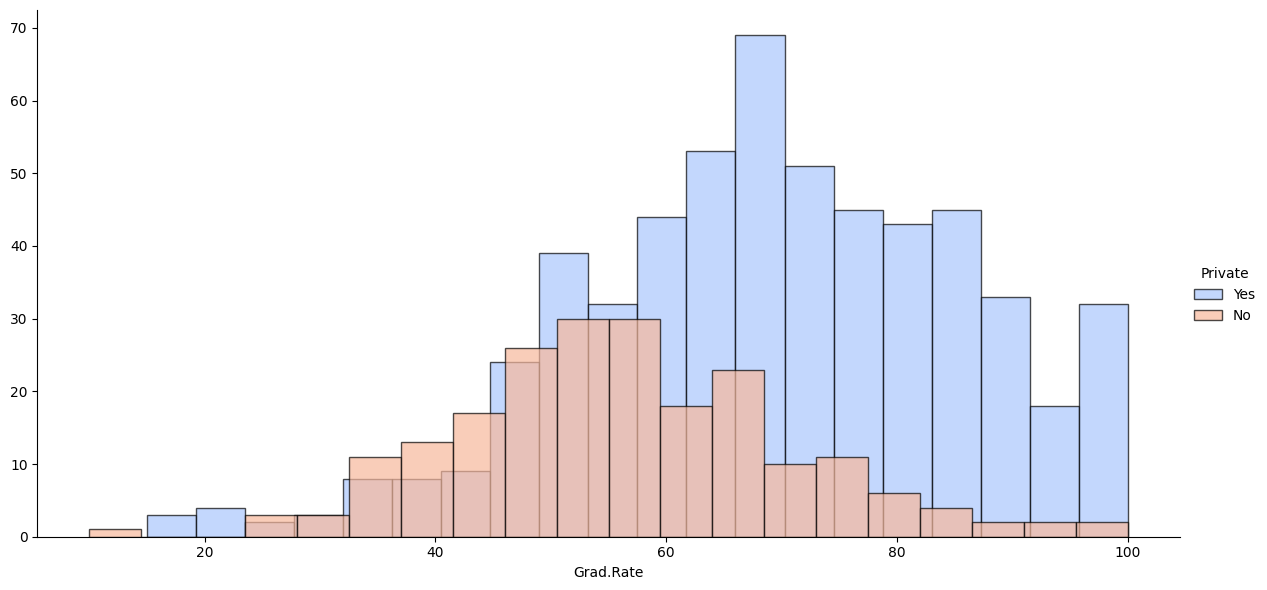

In [115]:
sns.FacetGrid(df, hue="Private", palette="coolwarm", height=6, aspect=2).map(
    plt.hist, "Grad.Rate", bins=20, alpha=0.7, edgecolor="black"
).add_legend()

## K Means Cluster Creation

It's now time to create the cluster labels!

**Import KMeans from SciKit Learn.**

In [116]:
from sklearn.cluster import KMeans

**Create an instance of a K Means model with 2 clusters.**

In [117]:
kmeans = KMeans(n_clusters=2)

**Fit the model to all the data except for the Private label.**

In [118]:
df_feat = df.drop("Private", axis=1)
df_target = df["Private"]

df_feat.shape, df_target.shape

((777, 17), (777,))

In [119]:
kmeans.fit(df_feat)

KMeans(n_clusters=2)

** What are the cluster center vectors?**

In [120]:
kmeans.cluster_centers_

array([[1.99097222e+03, 1.34700585e+03, 5.01001462e+02, 2.66637427e+01,
        5.46023392e+01, 2.19326316e+03, 5.53080409e+02, 1.06887091e+04,
        4.37517398e+03, 5.44059942e+02, 1.26739474e+03, 7.10745614e+01,
        7.83391813e+01, 1.38330409e+01, 2.35716374e+01, 9.58258772e+03,
        6.58815789e+01],
       [1.04349247e+04, 6.95977419e+03, 2.83176344e+03, 3.41397849e+01,
        6.45806452e+01, 1.47810323e+04, 3.07806452e+03, 8.61637634e+03,
        4.22773118e+03, 5.88516129e+02, 1.87936559e+03, 8.43225806e+01,
        8.97311828e+01, 1.59774194e+01, 1.66559140e+01, 1.02307849e+04,
        6.21935484e+01]])

## Evaluation

There is no perfect way to evaluate clustering if you don't have the labels, but since this is just an exercise, we do have the labels, so we'll take advantage of this to evaluate our clusters. Keep in mind that you usually won't have this luxury in the real world.

**Create a new column for df called "Cluster", which is 1 for a private school and 0 for a public school.**

In [121]:
df["Cluster"] = kmeans.labels_

In [131]:
df["Cluster"].head()

Abilene Christian University    0
Adelphi University              0
Adrian College                  0
Agnes Scott College             0
Alaska Pacific University       0
Name: Cluster, dtype: int32

In [123]:
df_target

Abilene Christian University      Yes
Adelphi University                Yes
Adrian College                    Yes
Agnes Scott College               Yes
Alaska Pacific University         Yes
                                 ... 
Worcester State College            No
Xavier University                 Yes
Xavier University of Louisiana    Yes
Yale University                   Yes
York College of Pennsylvania      Yes
Name: Private, Length: 777, dtype: object

In [124]:
df_target_numeric = df_target.map({"Yes":1,"No":0})

**Create a confusion matrix and a classification report to see how well the Kmeans clustering worked without receiving labels.**

In [132]:
df["Cluster"].value_counts(), df_target_numeric.value_counts()

(Cluster
 0    684
 1     93
 Name: count, dtype: int64,
 Private
 1    565
 0    212
 Name: count, dtype: int64)

In [125]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(df_target_numeric, df["Cluster"]))

[[131  81]
 [553  12]]


Here's an ASCII representation of the confusion matrix:
```
           Predicted
           0   |   1
         -------------
 Actual 0 | TN  |  FP
        1 | FN  |  TP
```
 Where:
- TP = True Positives
- TN = True Negatives
- FP = False Positives
- FN = False Negatives


In [126]:
print(classification_report(df_target_numeric, df["Cluster"]))

              precision    recall  f1-score   support

           0       0.19      0.62      0.29       212
           1       0.13      0.02      0.04       565

    accuracy                           0.18       777
   macro avg       0.16      0.32      0.16       777
weighted avg       0.15      0.18      0.11       777



Not bad considering the algorithm only uses features to group universities into 2 distinct clusters! I hope you can start to see how K Means is useful for clustering unlabeled data!


In [127]:
df

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Cluster
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,0
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,0
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,0
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,0
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40,0
Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83,0
Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49,0
Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99,0


In [128]:
df["Private"].value_counts()

Private
Yes    565
No     212
Name: count, dtype: int64

In [129]:
df_true = df[df_target_numeric == 1].sample(212)
df_false = df[df_target_numeric == 0]

df_equi = pd.concat([df_true, df_false])
df_equi.shape

(424, 19)

In [130]:
df_equi_feat = df_equi.drop("Private", axis=1)
df_equi_target = df_equi["Private"]

kmeans = KMeans(n_clusters=2)
kmeans.fit(df_equi_feat)
df_equi["Cluster"] = kmeans.labels_
df_equi_target_numeric = df_equi_target.map({"Yes": 1, "No": 0})
print(confusion_matrix(df_equi_target_numeric, df_equi["Cluster"]))
print(classification_report(df_equi_target_numeric, df_equi["Cluster"]))

[[  4 208]
 [ 58 154]]
              precision    recall  f1-score   support

           0       0.06      0.02      0.03       212
           1       0.43      0.73      0.54       212

    accuracy                           0.37       424
   macro avg       0.24      0.37      0.28       424
weighted avg       0.24      0.37      0.28       424

